In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sns.set()

In [15]:
class Precision():
    def __init__(self,file):
        df = pd.read_csv(file)
        self.df = df
        
    def plot_sigma(self,files,savefile):
        dat = {}
        print('lower case sigma, if file is uppercase sigma, switch')
        for f in files:
            sig = f.split('.csv')[0].split('sigma')[1].split('_Base')[0]
            if sig in dat.keys():
                dat[sig]=dat[sig].append(pd.read_csv(f,sep='\s+'))
            else:
                dat[sig] = pd.read_csv(f,sep='\s+')
        
        plots = len(files)
        i = 1
        for key in dat.keys():
            _,diffrecall = self.get_diffs(dat[key])
            plt.subplot(2,3,i)
            #plt.hist(diffrecall,range = (-0.01,0.01))
            plt.hist(diffrecall)
            plt.title('Sigma:{}'.format(float(key)))
            i+=1
        #plt.suptitle('Difference in Precision on Test Trials (Target-Output)')
        plt.tight_layout()
        plt.savefig(savefile)
            
    def get_diffs(self,df):
        df_include= []
        for i in df['$TrialName']:
            if 'Recall' in i:
                df_include.append('True')
            else:
                df_include.append('False')
        df.index = df_include
        df_recall = df.loc['True']

        #pull out target and actual decoded output for recall and all trials
        decodeout = df['#OutDecode']
        target = df['#OutTarget']
        decodeout_recall = df_recall['#OutDecode']
        target_recall = df_recall['#OutTarget']

        
        diff =np.array(decodeout)-np.array(target)
        self.alldiff = diff
        diffrecall =np.array(decodeout_recall)-np.array(target_recall)
        self.recalldiff = diffrecall
        return diff,diffrecall
        

    def plot_diffinperf(self,savefile):
        df = self.df
        diff,diffrecall= self.get_diffs(df)
        #make dataframe for just recall
        
        plt.subplot(1,2,1)
        plt.hist(diff)
        plt.xlabel('Difference')
        plt.ylabel('Frequency')
        plt.title('All Test Trials')
        plt.subplot(1,2,2)
        
        #plt.hist(diffrecall, range = (-0.01,0.01))
        plt.hist(diffrecall)
        plt.xlabel('Difference')
        plt.title('Recall Test Trials')
        plt.suptitle('Difference in Precision on Test Trials (Target-Output)')
        plt.savefig(savefile)
    
    def plot_var_lesions(self,files,lesion_names,savefile):
        dat = {}
        for l in lesion_names:
            for f in files:
                if l in f:
                    if l in dat.keys():
                        dat[l]=dat[l].append(pd.read_csv(f))
                    else:
                        dat[l] = pd.read_csv(f) 
        self.lesiondat = dat
        plots = len(lesion_names)
        i = 1
        for key in dat.keys():
            _,diffrecall = self.get_diffs(dat[key])
            plt.subplot(2,2,i)
            #plt.hist(diffrecall,range = (-0.01,0.01))
            plt.hist(diffrecall)
            plt.title('Lesion:{}'.format(key))
            i+=1
        #plt.suptitle('Difference in Precision on Test Trials (Target-Output)')
        plt.tight_layout()
        plt.savefig(savefile)
        

lower case sigma, if file is uppercase sigma, switch


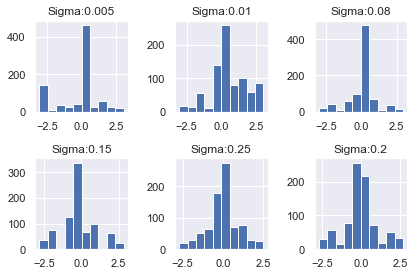

In [16]:
import os
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/'
files = os.listdir(base)
files_sigma = []
for f in files:
    if 'model'in f: #can use this to select for specific threshold values 
        files_sigma.append(base+f)

A = Precision(base+'model0_sigma0.005_Base.csv')
A.plot_sigma(files_sigma,'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis'+'PrecisionvariousSigmaSir2Thres15Models.png')

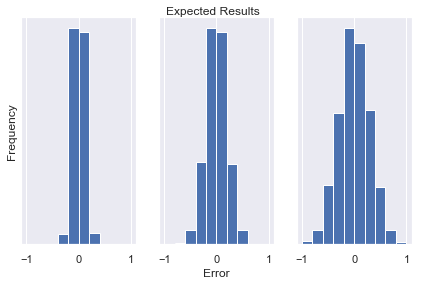

In [131]:
plt.subplot(1,3,1)
x = np.random.normal(0,0.1,10000)
plt.hist(x,range = [-1,1])
plt.yticks([])
plt.ylabel('Frequency')
#plt.title('No Lesion')
plt.subplot(1,3,2)
x = np.random.normal(0,0.2,10000)
plt.hist(x,range = [-1,1])
plt.xlabel('Error')
#plt.ylabel('Frequency')
#plt.title('Lesion')
plt.yticks([])
plt.subplot(1,3,3)
x = np.random.normal(0,0.3,10000)
plt.hist(x,range = [-1,1])
#plt.xlabel('Error')
#plt.ylabel('Frequency')
plt.yticks([])
plt.suptitle('Expected Results')
plt.tight_layout()
plt.show()

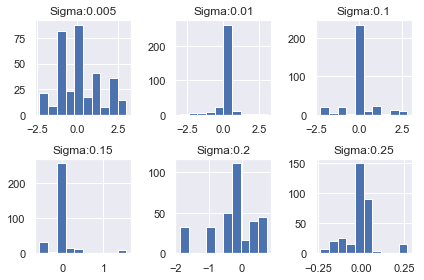

In [59]:
A = Precision(base+'Threshold3.4Sigma0.005.csv')
A.plot_sigma(files_sigma,'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis'+'PrecisionvariousSigmaSir2.png')

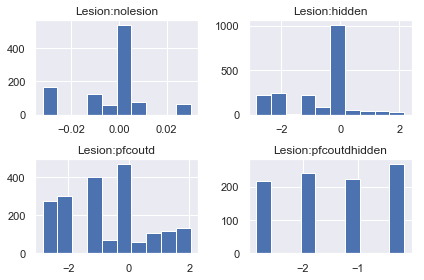

In [92]:
import os
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir1/'
files = os.listdir(base)
files_lesion = []
for f in files:
    #if np.logical_and('sig0.15'in f,'2' not in f): #can use this to select for specific threshold values 
    if 'sig0.15' in f:
        files_lesion.append(base+f)
lesion = Precision(base+'sig0.15hiddenlesion.csv')
lesion.plot_var_lesions(files_lesion, ['nolesion','hidden','pfcoutd','pfcoutdhidden'],base+'lesions_sir1_sig0.15.png')

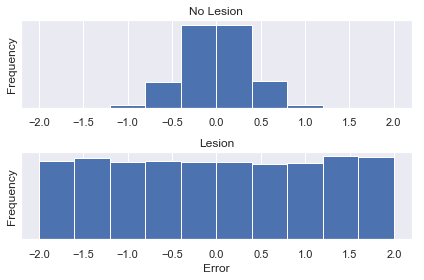

In [116]:
plt.subplot(2,1,1)
x = np.random.normal(0,0.35,10000)
plt.hist(x,range = [-2,2])
plt.yticks([])
plt.ylabel('Frequency')
plt.title('No Lesion')
plt.subplot(2,1,2)
x = np.random.uniform(-2,2,10000)
plt.hist(x)
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.title('Lesion')
plt.yticks([])
#plt.suptitle('Expected Results')
plt.tight_layout()
plt.show()

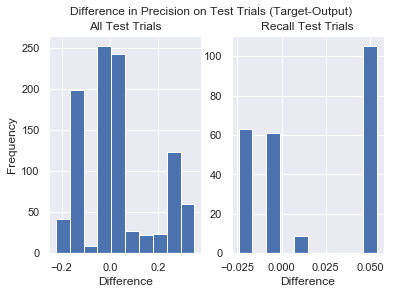

In [28]:
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir1/'
B = Precision(base+'lesionhidden')
B.plot_diffinperf('C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis'+'sir1lesionhidden.png')

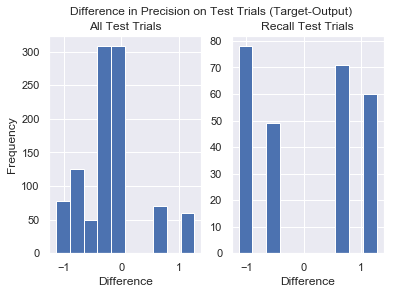

In [29]:
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir1/'
B = Precision(base+'lesionPFCoutD.csv')
B.plot_diffinperf('C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis'+'sir1lesionPFCoutD.png')

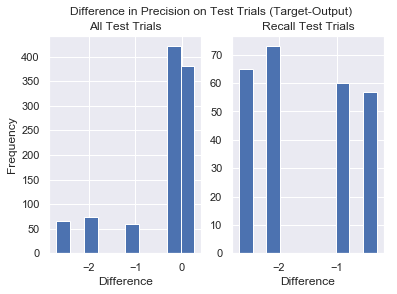

In [30]:
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir1/'
B = Precision(base+'lesionPFCoutDhidden.csv')
B.plot_diffinperf('C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis'+'sir1lesionPFCoutD.png')

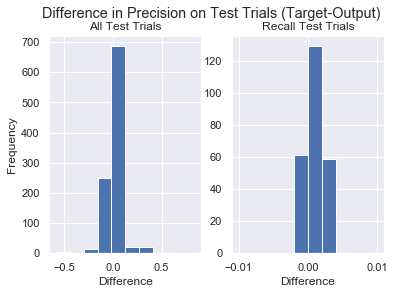

In [165]:
A = Precision(base+'TestData/1000TrialsSigma0.1.csv')
A.plot_diffinperf(base+'DiffinPerf.png')

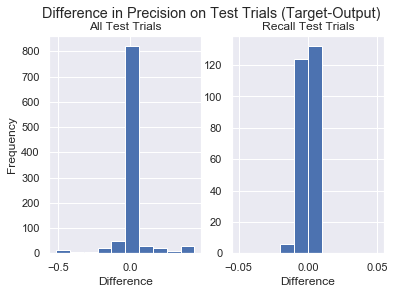

In [116]:
A = Precision('C:/Users/Aneri/go/src/sims/ch10/sir_proj/sir1/workingmemory/TestData/tsttrllogdata1000.csv')
A.plot_diffinperf('C:/Users/Aneri/go/src/sims/ch10/sir_proj/sir1/workingmemory/DifferenceinPerf1000.png')

In [77]:
df = pd.read_csv('Desktop/tsttrllogdata500.csv')

In [78]:
#make dataframe for just recall
df_include= []
for i in df['$TrialName']:
    if 'Recall' in i:
        df_include.append('True')
    else:
        df_include.append('False')
df.index = df_include
df_recall = df.loc['True']

In [79]:
#pull out target and actual decoded output for recall and all trials
decodeout = df['#OutDecode']
target = df['#OutTarget']
decodeout_recall = df_recall['#OutDecode']
target_recall = df_recall['#OutTarget']

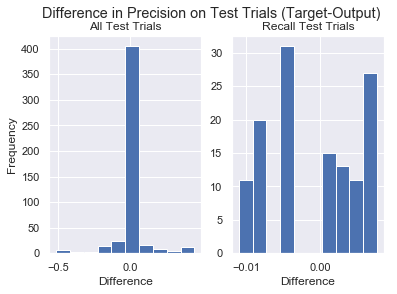

In [80]:
plt.subplot(1,2,1)
diff =np.array(decodeout)-np.array(target)
plt.hist(diff)
plt.xlabel('Difference')
plt.ylabel('Frequency')
plt.title('All Test Trials')
plt.subplot(1,2,2)
diff =np.array(decodeout_recall)-np.array(target_recall)
plt.hist(diff)
plt.xlabel('Difference')
plt.title('Recall Test Trials')
plt.suptitle('Difference in Precision on Test Trials (Target-Output)')
plt.show()

In [ ]:
diff =np.array(decodeout)-np.array(target)
plt.hist(diff)
plt.xlabel('Difference')
plt.ylabel('Frequency')
plt.title('Difference in Precision on Recall Test Trials (Target - Output)')
plt.show()

In [22]:
cor = []
for i in trial_name:
    if '_A_mnt' in i:
        cor.append(0)
    if '_B_mnt' in i:
        cor.append(1)
    if '_C_mnt' in i:
        cor.append(2)
    if '_D_mnt' in i:
        cor.append(3)
out = []
for i in decodeout:
    out.append(i)

In [28]:
cor

[1, 0, 3, 2, 0, 3, 2, 1, 0, 1, 1, 2, 1, 1, 0, 0, 0, 1, 2, 2]

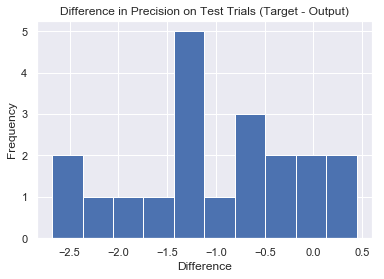

In [34]:
diff =np.array(cor)-np.array(out)
plt.hist(diff)
plt.xlabel('Difference')
plt.ylabel('Frequency')
plt.title('Difference in Precision on Test Trials (Target - Output)')
plt.show()